# Analysis of Large Language Models on Input Method Editor Tasks

## Setup

### Libraries

In [19]:
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import pandas as pd
import numpy as np

### Google Drive

In [20]:
from google.colab import drive
drive.mount('/content/drive')
# drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [21]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

In [22]:
all_results = gc.open('Overall LLMs Result_Final')#'Overall LLMs Results_Figures')
tasks = ['Chinese Words_Generation', 'Chinese Sentence_Generation', 'Japanese Words_Generation', 'Japanese Sentence_Generation', 'Chinese Error Correction', 'Japanese Error Correction']

### Constants

In [23]:
MODELS_METADATA = pd.DataFrame(gc.open('All Models').worksheet('Information').get_all_records()).set_index('Key');
MODELS_METADATA
#gemini25

,Name,Type
Key,,
P2H_HMM,P2H_HMM,baseline
P2H_DAG,P2H_DAG,baseline
sys_pinyin,macOS Pinyin,baseline
sys_japanese,macOS Romaji,baseline
opennmt,OpenNMT,baseline
pycorrector,pycorrector,baseline
qwen2,Qwen2-7B,local
baichuan2,Baichuan2-7B,local
claude3,Claude 3 Sonnet,online


In [24]:
FIGURES_FOLDER = '/content/drive/MyDrive/LLM exploration project/Figures'

### Functions

In [25]:
def get_model_type(model):
  return MODELS_METADATA.loc[model, 'Type']

def get_model_name(model):
  return MODELS_METADATA.loc[model, 'Name']

In [26]:
def load_results(task):
  sheet = all_results.worksheet(task)

  # check for nonunique headers
  headers = sheet.row_values(1)
  header_counts = Counter(headers)
  duplicates = [header for header, count in header_counts.items() if count > 1]

  if duplicates:
    print(f"Duplicated headers found: {duplicates}")

  data = sheet.get_all_records()
  df = pd.DataFrame(data)

  return df

In [27]:
def extract_gen_models(df):
  models = list(filter(lambda x: x.split('_')[-1] == 'gen', df.columns.values)) # filter out all gen models from columns
  models = list(set([x[:-4] for x in models])) # strip out model names

  return models

In [28]:
def extract_err_models(df):
  models = list(filter(lambda x: x[-21:] == '_incorrectstrings_gen', df.columns.values)) # filter out all gen models from columns
  models = list(set([x[:-21] for x in models])) # strip out model names

  return models

In [29]:
def make_columns_numeric(df, models):
  for model in models:
    df[model + '_simhash_textsim'] = pd.to_numeric(
        df[model + '_simhash_textsim'], errors='coerce'
    )

    df[model + '_time'] = pd.to_numeric(
        df[model + '_time'], errors='coerce'
    )

## Chinese Word Generation

### Processing

Fetch task results and models.

In [ ]:
df = load_results('Chinese Words_Generation')
models = extract_gen_models(df)

make_columns_numeric(df, models)

In [ ]:
models

['mistral',
 'llama3',
 'gpt4',
 'claude3',
 'baichuan2',
 'P2H_HMM',
 'gemini25',
 'P2H_DAG',
 'gpt4o',
 'qwen2',
 'GLM4',
 'gemini2',
 'sys_pinyin',
 'claude35',
 'llama32']

### All Results

Create index and columns for DataFrame. Will hold models mean performance for text similarity and time.

In [ ]:
models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = ['textsim', 'time']

Create and populate the DataFrame.

In [ ]:
mean_df = pd.DataFrame(index=models_index, columns=columns, dtype='float64')

for model in models:
    mean_df.loc[(get_model_type(model), model), 'textsim'] = df[model + '_simhash_textsim'].mean()
    mean_df.loc[(get_model_type(model), model), 'time'] = df[model + '_time'].mean()

In [ ]:
mean_df

textsim      time
baseline P2H_DAG     0.805772  0.000302
         P2H_HMM     0.713186  0.317423
         sys_pinyin  0.820585  0.457356
local    GLM4        0.601718  0.325582
         baichuan2   0.588522  3.103892
         qwen2       0.696636  0.990473
online   claude3     0.665960  1.572528
         claude35    0.686450  2.848633
         gemini2     0.808412  0.689039
         gemini25    0.716564  0.414091
         gpt4        0.762379  1.909118
         gpt4o       0.809968  0.980912
         llama3      0.581429  5.050007
         llama32     0.542704  0.369537
         mistral     0.571961  0.751265

### Selected Results

In [ ]:
selected_models = ['gpt4o', 'gemini2','llama3', 'llama32', 'GLM4', 'sys_pinyin']

Extract selected data.

In [ ]:
selected_mean_df = mean_df.loc[pd.IndexSlice[:, selected_models], :]

In [ ]:
selected_mean_df

textsim      time
online   gpt4o       0.809968  0.980912
         gemini2     0.808412  0.689039
         llama3      0.581429  5.050007
         llama32     0.542704  0.369537
local    GLM4        0.601718  0.325582
baseline sys_pinyin  0.820585  0.457356

### Attribute Analysis

#### Text Similarity vs Word Length

##### Table

In [ ]:
models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['wl'].unique()

In [ ]:
data = pd.DataFrame(index=models_index, columns=columns, dtype='float64')

for model in models:
  for wl in columns:
    data.loc[(get_model_type(model), model), wl] = df[df['wl'] == wl][model + '_simhash_textsim'].mean()

data

2         3         4         5         6  \
baseline P2H_DAG     0.740823  0.877147  0.680909  0.868151  0.864479   
         P2H_HMM     0.741363  0.765642  0.621887  0.751094  0.682896   
         sys_pinyin  0.620185  0.871998  0.729543  0.905217  0.918535   
local    GLM4        0.568936  0.608684  0.551842  0.692581  0.568657   
         baichuan2   0.576635  0.586084  0.543767  0.657967  0.563555   
         qwen2       0.668863  0.713694  0.613543  0.723958  0.722899   
online   claude3     0.621584  0.672468  0.692857  0.741814  0.576531   
         claude35    0.637583  0.700517  0.602577  0.761811  0.704116   
         gemini2     0.677817  0.836378  0.692482  0.873737  0.876557   
         gemini25    0.679649  0.757326  0.584493  0.750575  0.720669   
         gpt4        0.671174  0.777454  0.630859  0.837720  0.848664   
         gpt4o       0.712145  0.803303  0.688629  0.886424  0.835717   
         llama3      0.539987  0.571576  0.541597  0.693038  0.562650   
         llama32     0.551754  0.538690  0.512118  0.573141  0.529972   
         mistral     0.566882  0.589539  0.549567  0.616873  0.556030   

                            7         8         9  
baseline P2H_DAG     0.836456  0.770307  0.669624  
         P2H_HMM     0.674968  0.662542  0.766230  
         sys_pinyin  0.940277  0.918784  0.768584  
local    GLM4        0.642555  0.597037  0.625458  
         baichuan2   0.607307  0.592718  0.634761  
         qwen2       0.764008  0.695223  0.606148  
online   claude3     0.691764  0.680811  0.819158  
         claude35    0.710229  0.756068  0.581235  
         gemini2     0.889910  0.934136  0.856731  
         gemini25    0.761741  0.789543  0.717981  
         gpt4        0.835725  0.814204  0.773173  
         gpt4o       0.914628  0.978040  0.833770  
         llama3      0.608149  0.601224  0.582663  
         llama32     0.553781  0.533731  0.546101  
         mistral     0.567140  0.539609  0.535701

##### Figures

Model Order

In [ ]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35',
                'gemini2','gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2',
                'qwen2', 'P2H_HMM', 'P2H_DAG', 'sys_pinyin']

All models on one bar chart

In [ ]:
#selected_data = data.loc[pd.IndexSlice[:, selected_models], :]

# plt.figure(figsize=(12, 6))  # Adjust figure size as needed
# sns.barplot(x='wl', y='textsim', hue='model', data=melted_df)
# plt.xlabel('Word Length')
# plt.ylabel('Text Similarity (Simhash)')
# plt.title('Chinese Word Generation: Text Similarity vs Word Length of All Models')
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside plot
# plt.tight_layout() #prevents legend cutoff
# plt.show()

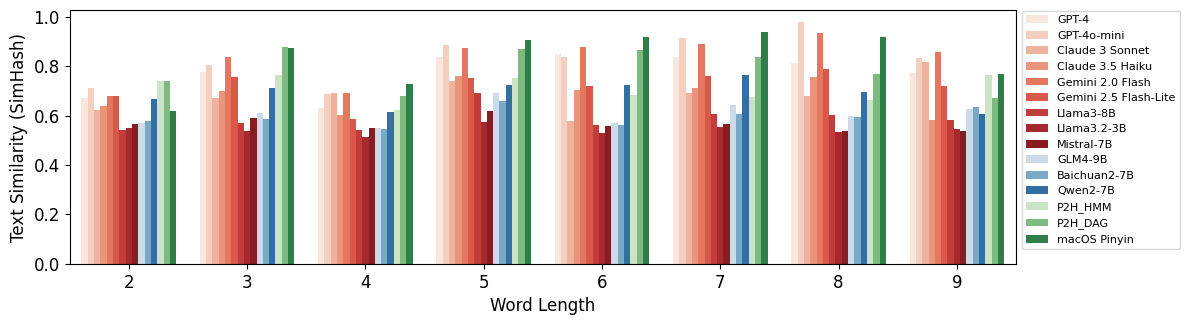

In [ ]:
melted_df = pd.melt(data.droplevel(0).reindex(models_order).rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')



# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': [ 'GLM4-9B', 'Baichuan2-7B', 'Qwen2-7B'],
    'Traditional IMEs': ['P2H_HMM', 'P2H_DAG', 'macOS Pinyin']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length', fontsize=12)
plt.ylabel('Text Similarity (SimHash)', fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/cwg_textsim_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Time vs Word Length

##### Table

In [ ]:
models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['wl'].unique()

In [ ]:
data = pd.DataFrame(index=models_index, columns=columns, dtype='float64')

for model in models:
  for wl in columns:
    data.loc[(get_model_type(model), model), wl] = df[df['wl'] == wl][model + '_time'].mean()

data

2         3         4         5         6  \
baseline P2H_DAG     0.000221  0.000212  0.000230  0.000249  0.000265   
         P2H_HMM     0.073984  0.272576  0.399985  0.266348  0.307560   
         sys_pinyin  0.264523  0.336685  0.426262  0.499984  0.568597   
local    GLM4        0.236137  0.252999  0.330481  0.333440  0.389166   
         baichuan2   2.096723  2.336564  3.135344  3.358450  3.738578   
         qwen2       0.474007  0.674267  0.884061  1.107340  1.287931   
online   claude3     1.146255  1.349553  1.631725  1.585345  1.670068   
         claude35    2.278786  2.994148  2.996064  3.002157  2.986996   
         gemini2     0.636876  0.636569  0.691064  0.760821  0.737901   
         gemini25    0.393247  0.400194  0.410073  0.405233  0.430272   
         gpt4        1.584814  1.734691  1.906610  1.987492  2.135974   
         gpt4o       0.984962  1.021030  0.956383  0.906513  0.956043   
         llama3      3.090843  3.759607  4.673735  5.178389  6.431450   
         llama32     0.236920  0.288424  0.357565  0.404415  0.457489   
         mistral     0.675745  0.680214  0.629009  0.849917  0.734722   

                            7         8          9  
baseline P2H_DAG     0.000279  0.001104   0.000251  
         P2H_HMM     0.434582  0.891810   0.474959  
         sys_pinyin  0.664902  0.738992   0.939873  
local    GLM4        0.432190  0.466446   0.509650  
         baichuan2   4.297109  4.532382   4.837011  
         qwen2       1.600557  1.708597   2.155909  
online   claude3     2.072208  2.194553   2.571091  
         claude35    3.013799  2.997975   3.130178  
         gemini2     0.729281  0.719343   0.727506  
         gemini25    0.447202  0.440462   0.499368  
         gpt4        2.271413  2.226132   2.250418  
         gpt4o       0.962794  1.095677   0.920682  
         llama3      6.813664  8.247262  12.336907  
         llama32     0.503234  0.535549   0.663746  
         mistral     0.961860  0.789341   1.395233

##### Figures

Model Order

In [ ]:
models_order = [ 'gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25',
                'llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2', 'P2H_HMM', 'P2H_DAG', 'sys_pinyin']

In [ ]:
melted_df = pd.melt(data.droplevel(0).reindex(models_order).rename(MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')
melted_df

,model,wl,time
0,GPT-4,2,1.584814
1,GPT-4o-mini,2,0.984962
2,Claude 3 Sonnet,2,1.146255
3,Claude 3.5 Haiku,2,2.278786
4,Gemini 2.0 Flash,2,0.636876
...,...,...,...
115,Baichuan2-7B,9,4.837011
116,Qwen2-7B,9,2.155909
117,P2H_HMM,9,0.474959
118,P2H_DAG,9,0.000251


All models on one bar chart

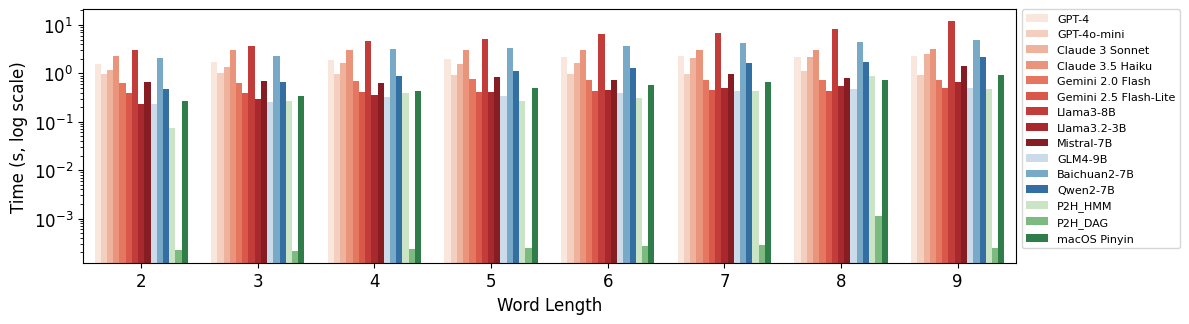

In [ ]:
# Define model categories

model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash', 'Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Baichuan2-7B', 'Qwen2-7B'],
    'Traditional IMEs': ['P2H_HMM', 'P2H_DAG', 'macOS Pinyin']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length', fontsize=12)
plt.yscale('log')
plt.ylabel('Time (s, log scale)', fontsize=12)
# plt.title('Chinese Word Generation: Time vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/cwg_time_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Chinese Sentence Generation

In [ ]:
df = load_results('Chinese Sentence_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

<Axes: xlabel='len', ylabel='Count'>

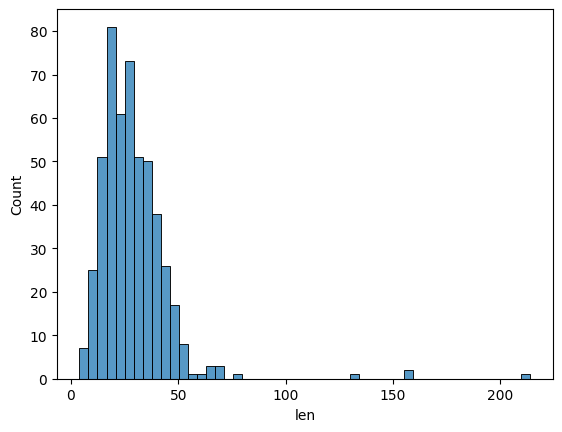

In [ ]:
sns.histplot(df['len'])

In [ ]:
# bucket of ranges
columns = ['4-14', '14-24', '24-34', '34-44', '44+']

df['len_bin'] = pd.cut(df['len'], bins=[4, 14, 24, 34, 44, np.inf], labels=columns)

In [ ]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  for sl in columns:
    data.loc[model, sl] = df[df['len_bin'] == sl][model + '_simhash_textsim'].mean()

data

,4-14,14-24,24-34,34-44,44+
claude35,0.859873,0.839350,0.834553,0.818644,0.788686
mistral,0.605585,0.579219,0.558440,0.561190,0.580312
baichuan2,0.639179,0.598033,0.573309,0.580494,0.565950
gpt4,0.917034,0.907563,0.880173,0.871035,0.828445
claude3,0.875641,0.856440,0.835977,0.806612,0.802733
llama3,0.648909,0.660497,0.613510,0.613606,0.580613
P2H_HMM,0.706433,0.731793,0.675179,0.669437,0.658358
gemini25,0.862915,0.811503,0.814295,0.808381,0.803190
P2H_DAG,0.693267,0.754907,0.714801,0.735908,0.720658
sys_pinyin,0.895121,0.858308,0.841524,0.822776,0.794791


Model Order

In [ ]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2', 'P2H_HMM', 'P2H_DAG', 'sys_pinyin']

In [ ]:
data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict())

,4-14,14-24,24-34,34-44,44+
GPT-4,0.917034,0.907563,0.880173,0.871035,0.828445
GPT-4o-mini,0.887830,0.847001,0.828538,0.820059,0.784626
Claude 3 Sonnet,0.875641,0.856440,0.835977,0.806612,0.802733
Claude 3.5 Haiku,0.859873,0.839350,0.834553,0.818644,0.788686
Gemini 2.0 Flash,0.925934,0.875678,0.877825,0.874527,0.851265
Gemini 2.5 Flash-Lite,0.862915,0.811503,0.814295,0.808381,0.803190
Llama3-8B,0.648909,0.660497,0.613510,0.613606,0.580613
Llama3.2-3B,0.567775,0.556680,0.530853,0.526804,0.514678
Mistral-7B,0.605585,0.579219,0.558440,0.561190,0.580312
GLM4-9B,0.683343,0.659515,0.649859,0.649690,0.664028


### Text Similarity Vs Sentence Length

In [ ]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25',
                'llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2', 'P2H_HMM', 'P2H_DAG', 'sys_pinyin']

In [ ]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')
melted_df

,model,wl,textsim
0,GPT-4,4-14,0.917034
1,GPT-4o-mini,4-14,0.887830
2,Claude 3 Sonnet,4-14,0.875641
3,Claude 3.5 Haiku,4-14,0.859873
4,Gemini 2.0 Flash,4-14,0.925934
...,...,...,...
70,Baichuan2-7B,44+,0.565950
71,Qwen2-7B,44+,0.640000
72,P2H_HMM,44+,0.658358
73,P2H_DAG,44+,0.720658


All models on one bar chart

In [ ]:
'''
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df)
plt.xlabel('Sentence Length')
plt.ylabel('Text Similarity (Simhash)')
plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length of All Models')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside plot
plt.tight_layout() #prevents legend cutoff
plt.show()
'''

"\nmelted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).\n                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')\n\nplt.figure(figsize=(12, 6))  # Adjust figure size as needed\nsns.barplot(x='wl', y='textsim', hue='model', data=melted_df)\nplt.xlabel('Sentence Length')\nplt.ylabel('Text Similarity (Simhash)')\nplt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length of All Models')\nplt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside plot\nplt.tight_layout() #prevents legend cutoff\nplt.show()\n"

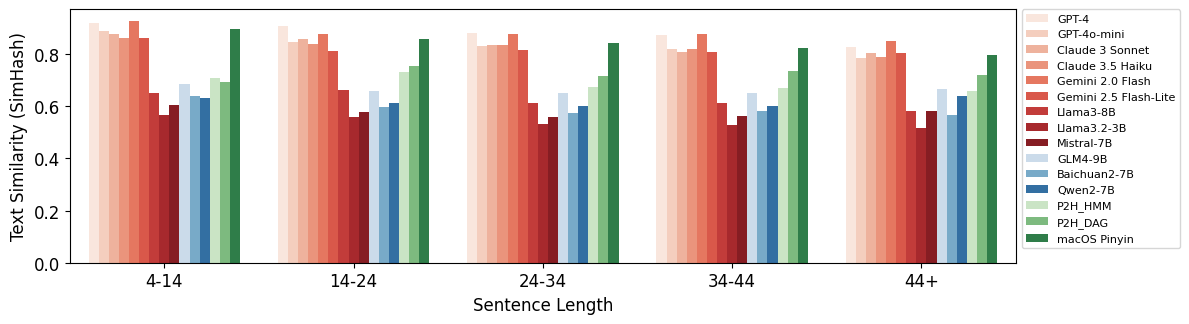

In [ ]:
#melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
'''
model_categories = {
        'Closed-Source LLMs': ['GPT-3.5', 'GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Baichuan2-7B', 'Qwen2-7B'],
    'Traditional IMEs': ['P2H_HMM', 'P2H_DAG', 'macOS Pinyin']
}
'''
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Baichuan2-7B', 'Qwen2-7B'],
    'Traditional IMEs': ['P2H_HMM', 'P2H_DAG', 'macOS Pinyin']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Sentence Length', fontsize=12)
plt.ylabel('Text Similarity (SimHash)', fontsize=12)

# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/csg_textsim_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()


### Time Vs Sentence Length

In [ ]:
df = load_results('Chinese Sentence_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

<Axes: xlabel='len', ylabel='Count'>

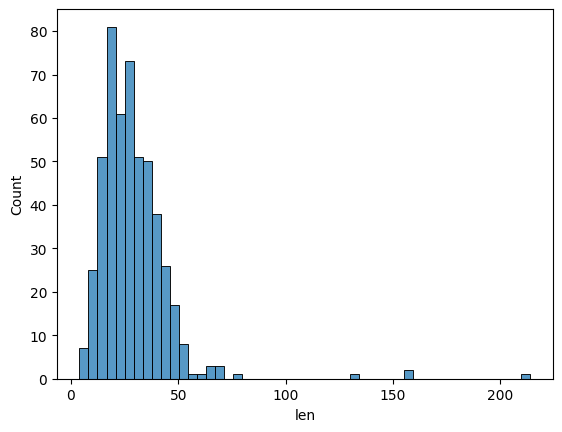

In [ ]:
sns.histplot(df['len'])

In [ ]:
# bucket of ranges
columns = ['4-14', '14-24', '24-34', '34-44', '44+']

df['len_bin'] = pd.cut(df['len'], bins=[4, 14, 24, 34, 44, np.inf], labels=columns)

In [ ]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  for sl in columns:
    data.loc[model, sl] = df[df['len_bin'] == sl][model + '_time'].mean()

data

,4-14,14-24,24-34,34-44,44+
claude35,2.309180,2.843063,3.112468,3.405885,4.502882
mistral,0.930376,1.053205,1.312989,1.496619,1.893162
baichuan2,0.868578,1.271851,2.747566,2.008281,2.752980
gpt4,1.838822,2.285570,2.713378,3.057214,3.996256
claude3,1.964653,2.401204,3.036117,3.545171,5.527964
llama3,1.043161,1.565357,2.417553,3.356839,5.830110
P2H_HMM,0.526258,0.836843,0.846899,1.115785,2.220337
gemini25,0.602415,0.637439,0.660747,0.695138,0.831357
P2H_DAG,0.000985,0.001193,0.001594,0.002372,0.006167
sys_pinyin,0.854740,1.435200,1.737398,2.562399,2.168277


In [ ]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2', 'P2H_HMM', 'P2H_DAG', 'sys_pinyin']

In [ ]:
data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict())

,4-14,14-24,24-34,34-44,44+
GPT-4,1.838822,2.285570,2.713378,3.057214,3.996256
GPT-4o-mini,1.050744,1.183508,1.464751,1.576690,1.914527
Claude 3 Sonnet,1.964653,2.401204,3.036117,3.545171,5.527964
Claude 3.5 Haiku,2.309180,2.843063,3.112468,3.405885,4.502882
Gemini 2.0 Flash,0.620747,0.722953,0.770254,0.799693,0.947933
Gemini 2.5 Flash-Lite,0.602415,0.637439,0.660747,0.695138,0.831357
Llama3-8B,1.043161,1.565357,2.417553,3.356839,5.830110
Llama3.2-3B,0.728931,1.017201,1.112756,1.104558,1.174059
Mistral-7B,0.930376,1.053205,1.312989,1.496619,1.893162
GLM4-9B,0.886884,1.289897,1.555054,1.858067,2.693944


In [ ]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')
melted_df

,model,wl,time
0,GPT-4,4-14,1.838822
1,GPT-4o-mini,4-14,1.050744
2,Claude 3 Sonnet,4-14,1.964653
3,Claude 3.5 Haiku,4-14,2.309180
4,Gemini 2.0 Flash,4-14,0.620747
...,...,...,...
70,Baichuan2-7B,44+,2.752980
71,Qwen2-7B,44+,5.294862
72,P2H_HMM,44+,2.220337
73,P2H_DAG,44+,0.006167


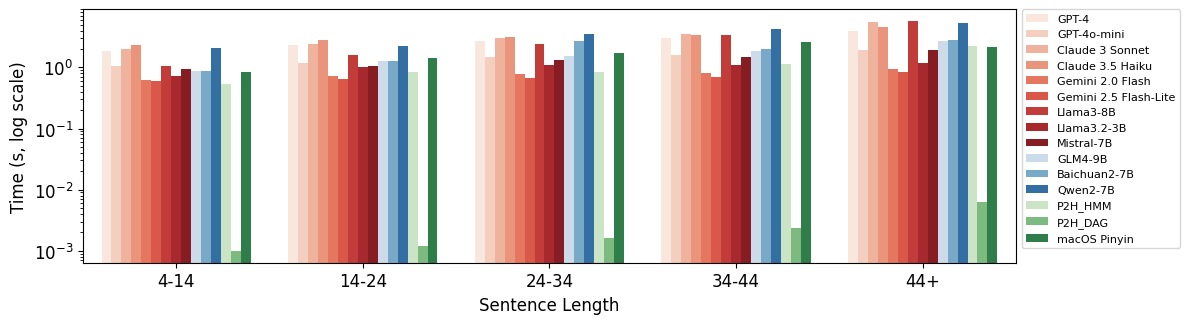

In [ ]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

# Define model categories
'''
model_categories = {
    'Closed-Source LLMs': ['GPT-3.5', 'GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Baichuan2-7B', 'Qwen2-7B'],
    'Traditional IMEs': ['P2H-DAG', 'P2H-HMM', 'macOS Pinyin']
}
'''

model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku','Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Baichuan2-7B', 'Qwen2-7B'],
    'Traditional IMEs': ['P2H_HMM', 'P2H_DAG', 'macOS Pinyin']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Sentence Length', fontsize=12)
plt.yscale('log')
plt.ylabel('Time (s, log scale)', fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/csg_time_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Japanese Words Generation

All Results

In [30]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [31]:
models.remove("wana")

In [32]:
models

['claude3',
 'llama32',
 'gpt4o',
 'rakuten',
 'swallow',
 'gemini2',
 'gpt35',
 'gpt4',
 'gemini',
 'claude35',
 'mistral',
 'GLM4',
 'gemini25',
 'llama3',
 'rinna',
 'sys_japanese',
 'rakuten2']

<Axes: xlabel='len', ylabel='Count'>

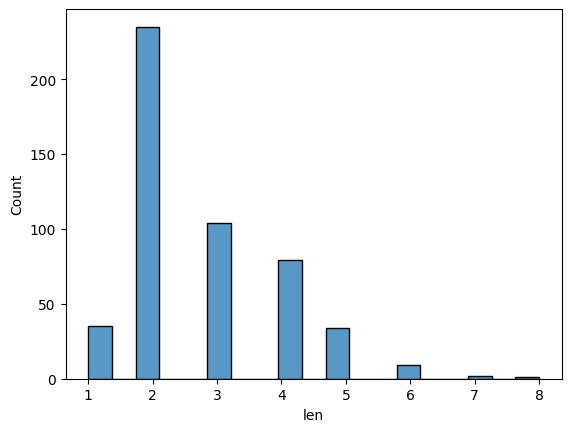

In [33]:
sns.histplot(df['len'])

In [ ]:
models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = ['textsim', 'time']

Create and populate the DataFrame.

In [ ]:
mean_df = pd.DataFrame(index=models_index, columns=columns, dtype='float64')

for model in models:
    mean_df.loc[(get_model_type(model), model), 'textsim'] = df[model + '_simhash_textsim'].mean()

    mean_df.loc[(get_model_type(model), model), 'time'] = df[model + '_time'].mean()

#for model in models:
#    mean_df.loc[(get_model_type(model), model), 'textsim'] = df[model + '_simhash_textsim'].mean()
#    mean_df.loc[(get_model_type(model), model), 'time'] = df[model + '_time'].mean()

In [ ]:
mean_df

In [41]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35','gemini2','gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2','swallow', 'rinna', 'sys_japanese']

#### Overall TextSimilarity VS Word length

In [42]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()


In [43]:
columns

array([2, 5, 3, 4, 1, 6, 7, 8])

In [44]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

#for model in models:
#    for wl in columns:
#        mask = (df['len'] == wl)
#        col_name = model + '_simhash_textsim'
#        if col_name in df.columns:
            # Convert to numeric, forcing invalid values like '' to NaN
#            numeric_series = pd.to_numeric(df.loc[mask, col_name], errors='coerce')
#            mean_val = numeric_series.mean()
#            data.loc[model, wl] = mean_val

for model in models:
    for wl in columns:
        mask = (df['len'] == wl)
        col_name = model + '_simhash_textsim'
        if col_name in df.columns:
            mean_val = df.loc[mask, col_name].mean()
            data.loc[model, wl] = mean_val


data

,2,5,3,4,1,6,7,8
claude3,0.740231,0.928604,0.818737,0.877098,0.605571,0.806397,0.765152,1.000000
llama32,0.561653,0.699202,0.661118,0.717690,0.541325,0.666667,0.810606,0.424242
gpt4o,0.771706,0.895624,0.794472,0.882739,0.635957,0.667703,0.780303,0.569231
rakuten,0.626501,0.768274,0.675994,0.776966,0.556565,0.716472,0.742424,1.000000
swallow,0.660308,0.819139,0.746663,0.771421,0.555231,0.664025,0.757576,1.000000
gemini2,0.823919,0.877212,0.852878,0.866740,0.668439,0.828283,1.000000,1.000000
gpt35,0.749813,0.763465,0.803389,0.801956,0.624529,0.522637,0.518415,0.453125
gpt4,0.771758,0.793189,0.820423,0.822508,0.640739,0.554623,0.427506,0.453125
gemini,0.724227,0.821095,0.797227,0.816429,0.625348,0.801347,0.795455,1.000000
claude35,0.764202,0.913553,0.825622,0.868373,0.601406,0.838384,0.765152,1.000000


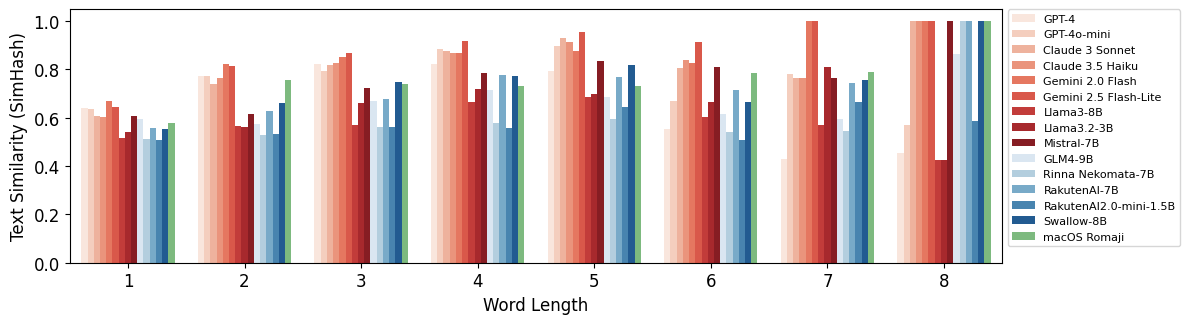

In [46]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku','Gemini 2.0 Flash', 'Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B',
'RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length', fontsize=12)
plt.ylabel('Text Similarity (SimHash)', fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_overall_textsim_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()


#### Overall Time VS Word length

In [47]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')
'''
for model in models:
    for wl in columns:
        mask = (df['len'] == wl)
        col_name = model + '_time'
        if col_name in df.columns:
            # Convert to numeric, forcing invalid values like '' to NaN
            numeric_series = pd.to_numeric(df.loc[mask, col_name], errors='coerce')
            mean_val = numeric_series.mean()
            data.loc[model, wl] = mean_val
data=data.drop(columns=[""])
'''

for model in models:
    for wl in columns:
        mask = (df['len'] == wl)
        col_name = model + '_time'
        if col_name in df.columns:
            mean_val = df.loc[mask, col_name].mean()
            data.loc[model, wl] = mean_val
data

,2,5,3,4,1,6,7,8
claude3,0.919746,0.867123,0.860448,1.010060,0.860794,0.798006,0.919095,0.688735
llama32,0.253431,0.347808,0.272374,0.312925,0.209257,0.425248,0.443135,0.448509
gpt4o,0.904535,0.872084,0.885487,0.872401,0.801853,0.815698,1.555523,0.728673
rakuten,3.519860,3.532041,3.530923,3.520510,3.521068,3.542644,3.509602,3.525851
swallow,3.922393,3.939710,3.892925,3.919713,3.807136,3.884951,3.968681,3.943387
gemini2,0.506720,0.502979,0.475914,0.492504,0.477938,0.494866,0.486947,0.511683
gpt35,0.749883,0.723627,0.763583,0.712699,0.719657,0.733979,0.705559,0.662779
gpt4,1.425646,1.459118,1.497537,1.460331,1.473832,1.457745,1.410330,1.378013
gemini,1.041971,1.110896,1.014558,1.122115,0.931704,0.732031,0.716007,0.639158
claude35,2.920693,3.089977,2.803728,2.931165,2.382024,3.736531,2.577634,2.536980


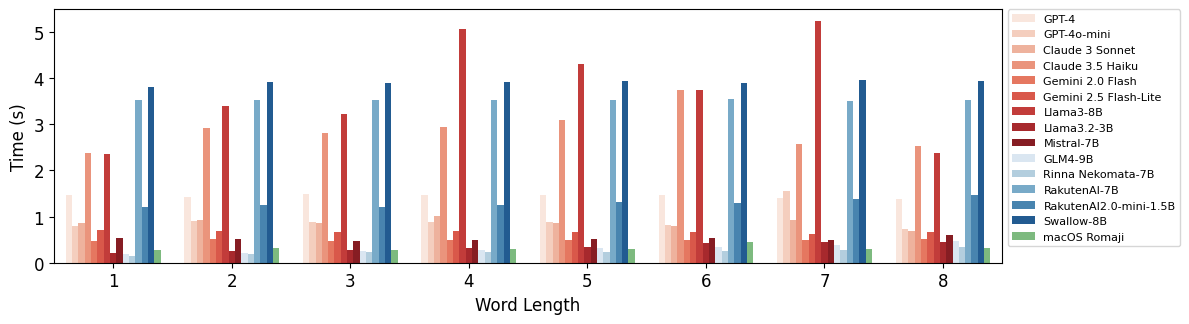

In [48]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash', 'Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B',
'RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length', fontsize=12)
plt.ylabel('Time (s)', fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_overall_time_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Text Similarity VS word lengths

In [49]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [50]:
models

['claude3',
 'llama32',
 'gpt4o',
 'rakuten',
 'swallow',
 'wana',
 'gemini2',
 'gpt35',
 'gpt4',
 'gemini',
 'claude35',
 'mistral',
 'GLM4',
 'gemini25',
 'llama3',
 'rinna',
 'sys_japanese',
 'rakuten2']

In [51]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35','gemini2', 'gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna', 'swallow','sys_japanese', 'wana']

In [52]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()


In [53]:
columns

array([2, 5, 3, 4, 1, 6, 7, 8])

#### Kanji

In [54]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [55]:
models.remove("wana")

In [56]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35','gemini2', 'gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna','swallow', 'sys_japanese']

In [57]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()
columns

array([2, 5, 3, 4, 1, 6, 7, 8])

In [58]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
    for wl in columns:
        mask = (df['len'] == wl) & (df['AI_type'] == "kanji")
        col_name = model + '_simhash_textsim'
        if col_name in df.columns:
           # numeric_series = pd.to_numeric(df.loc[mask, col_name], errors='coerce')
            #mean_val = numeric_series.mean()
            #data.loc[model, wl] = mean_val
            mean_val = df.loc[mask, col_name].mean()
            data.loc[model, wl] = mean_val

data

,2,5,3,4,1,6,7,8
claude3,0.710355,0.858974,0.655831,0.655384,0.605571,0.631313,NaN,NaN
llama32,0.529822,0.546519,0.517237,0.528420,0.541325,0.535354,NaN,NaN
gpt4o,0.746261,0.781132,0.606857,0.655670,0.635957,0.644522,NaN,NaN
rakuten,0.580614,0.597414,0.526154,0.521479,0.556565,0.497902,NaN,NaN
swallow,0.621076,0.521510,0.547521,0.505195,0.555231,0.507226,NaN,NaN
gemini2,0.803765,0.849359,0.725426,0.621297,0.668439,0.696970,NaN,NaN
gpt35,0.723418,0.591323,0.615519,0.563754,0.624529,0.510101,NaN,NaN
gpt4,0.746320,0.593217,0.659494,0.565503,0.640739,0.510101,NaN,NaN
gemini,0.698823,0.805883,0.677061,0.646759,0.625348,0.550505,NaN,NaN
claude35,0.737700,0.796413,0.659985,0.603392,0.601406,0.727273,NaN,NaN


In [59]:
data_melt = data.drop(columns=[7,8])
melted_df = pd.melt(data_melt.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')
melted_df

,model,wl,textsim
0,GPT-4,2,0.746320
1,GPT-4o-mini,2,0.746261
2,Claude 3 Sonnet,2,0.710355
3,Claude 3.5 Haiku,2,0.737700
4,Gemini 2.0 Flash,2,0.803765
...,...,...,...
85,RakutenAI-7B,6,0.497902
86,RakutenAI2.0-mini-1.5B,6,0.573737
87,Rinna Nekomata-7B,6,0.609169
88,Swallow-8B,6,0.507226


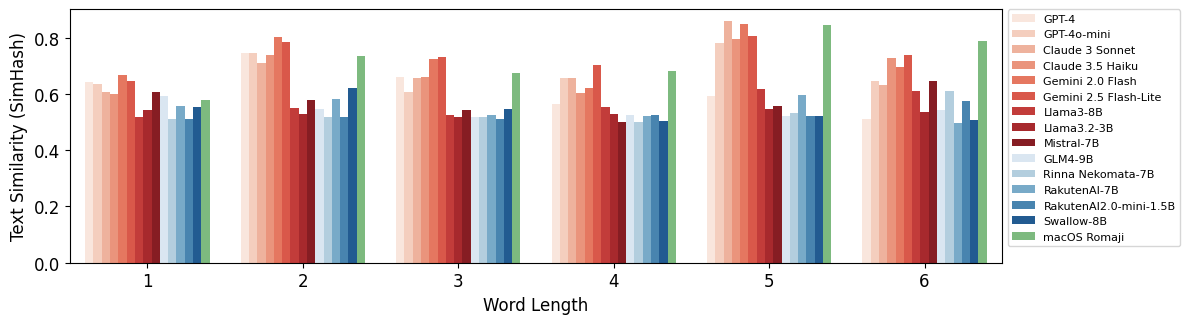

In [60]:
#melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku','Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_kanji_textsim_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



#### Hira

In [61]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [63]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35','gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna','swallow','sys_japanese', 'wana']

In [64]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()
columns

array([2, 5, 3, 4, 1, 6, 7, 8])

In [65]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
    for wl in columns:
        mask = (df['len'] == wl) & (df['AI_type'] == "hira")
        col_name = model + '_simhash_textsim'
        if col_name in df.columns:
            mean_val = df.loc[mask, col_name].mean()
            data.loc[model, wl] = mean_val



data

,2,5,3,4,1,6,7,8
claude3,0.954545,0.971591,1.000000,0.971659,NaN,1.000000,1.000000,NaN
llama32,0.901570,0.832334,0.951365,0.840299,NaN,0.858586,1.000000,NaN
gpt4o,0.954545,0.939394,1.000000,0.960736,NaN,0.666667,1.000000,NaN
rakuten,0.954545,0.843640,0.902914,0.898287,NaN,0.823232,1.000000,NaN
swallow,0.933986,0.907767,0.949675,0.859989,NaN,0.707071,1.000000,NaN
wana,0.954545,0.969231,1.000000,0.971659,NaN,1.000000,1.000000,NaN
gemini2,0.976874,0.936133,1.000000,0.960908,NaN,1.000000,1.000000,NaN
gpt35,0.954545,0.820466,1.000000,0.884923,NaN,0.492152,0.430769,NaN
gpt4,0.954545,0.844537,0.981602,0.909806,NaN,0.497203,0.430769,NaN
gemini,0.931873,0.829300,1.000000,0.875886,NaN,1.000000,1.000000,NaN


In [66]:
data_melt = data.drop(columns=[1,8])
melted_df = pd.melt(data_melt.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')
melted_df

,model,wl,textsim
0,GPT-4,2,0.954545
1,GPT-4o-mini,2,0.954545
2,Claude 3 Sonnet,2,0.954545
3,Claude 3.5 Haiku,2,0.954545
4,Gemini 2.0 Flash,2,0.976874
...,...,...,...
91,RakutenAI2.0-mini-1.5B,7,0.757576
92,Rinna Nekomata-7B,7,0.560606
93,Swallow-8B,7,1.000000
94,macOS Romaji,7,1.000000


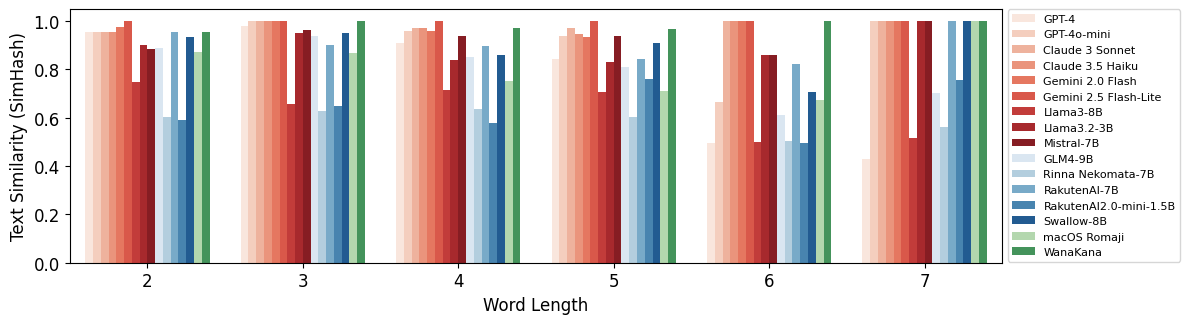

In [67]:
#melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
model_categories = {
    'Closed-Source LLMs': [ 'GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji', 'WanaKana']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_hira_textsim_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



#### Kata

In [68]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [69]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna', 'swallow', 'sys_japanese', 'wana']

In [70]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()
columns.sort()
columns

array([1, 2, 3, 4, 5, 6, 7, 8])

In [71]:
for model in models:
  for wl in columns:
      if wl in [7, 8]:
          # 把7和8都视为同一个“7+”类别
          col_label = '7+'
          mask = (df['len'].isin([7, 8])) & (df['AI_type'] == 'kata')
      else:
          col_label = wl
          mask = (df['len'] == wl) & (df['AI_type'] == 'kata')

      col_name = model + '_simhash_textsim'
      if col_name in df.columns:
          mean_val = df.loc[mask, col_name].mean()
          data.loc[model, col_label] = mean_val



data

,2,5,3,4,1,6,7,8,7+
claude3,0.948485,0.915530,0.960227,0.935065,NaN,0.787879,1.000000,NaN,0.765152
llama32,0.571544,0.608337,0.634237,0.638528,NaN,0.606061,1.000000,NaN,0.522727
gpt4o,0.948485,0.917188,0.961189,1.000000,NaN,0.691919,1.000000,NaN,0.564918
rakuten,0.948485,0.784375,0.735907,0.805817,NaN,0.828283,1.000000,NaN,0.742424
swallow,0.948485,0.915436,0.941288,0.917749,NaN,0.777778,1.000000,NaN,0.757576
wana,0.948485,0.717184,0.738685,0.753628,NaN,0.898990,1.000000,NaN,0.787879
gemini2,0.948485,0.805222,0.957382,0.963203,NaN,0.787879,1.000000,NaN,1.000000
gpt35,0.904545,0.809977,0.981061,0.921445,NaN,0.565657,0.430769,NaN,0.529593
gpt4,0.948485,0.871010,0.981061,0.958242,NaN,0.656566,0.430769,NaN,0.438684
gemini,0.853030,0.820135,0.821018,0.900433,NaN,0.853535,1.000000,NaN,0.795455


In [72]:
desired_order = [2, 3, 4, 5, 6, '7+']
data_melt = data[desired_order]
data_melt

,2,3,4,5,6,7+
claude3,0.948485,0.960227,0.935065,0.915530,0.787879,0.765152
llama32,0.571544,0.634237,0.638528,0.608337,0.606061,0.522727
gpt4o,0.948485,0.961189,1.000000,0.917188,0.691919,0.564918
rakuten,0.948485,0.735907,0.805817,0.784375,0.828283,0.742424
swallow,0.948485,0.941288,0.917749,0.915436,0.777778,0.757576
wana,0.948485,0.738685,0.753628,0.717184,0.898990,0.787879
gemini2,0.948485,0.957382,0.963203,0.805222,0.787879,1.000000
gpt35,0.904545,0.981061,0.921445,0.809977,0.565657,0.529593
gpt4,0.948485,0.981061,0.958242,0.871010,0.656566,0.438684
gemini,0.853030,0.821018,0.900433,0.820135,0.853535,0.795455


In [73]:

melted_df = pd.melt(data_melt.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')
melted_df

,model,wl,textsim
0,GPT-4,2,0.948485
1,GPT-4o-mini,2,0.948485
2,Claude 3 Sonnet,2,0.948485
3,Claude 3.5 Haiku,2,0.948485
4,Gemini 2.0 Flash,2,0.948485
...,...,...,...
91,RakutenAI2.0-mini-1.5B,7+,0.580186
92,Rinna Nekomata-7B,7+,0.765152
93,Swallow-8B,7+,0.757576
94,macOS Romaji,7+,0.787879


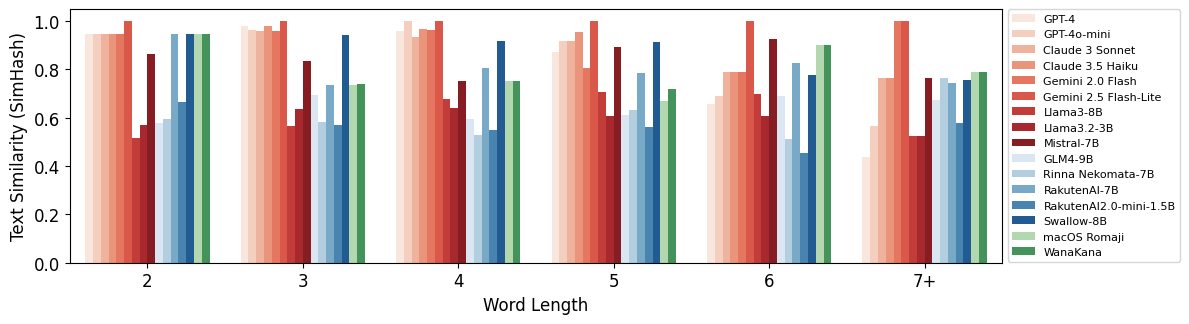

In [74]:
#melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji', 'WanaKana']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_kata_textsim_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



### Time VS word lengths

#### Kanji

In [77]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [78]:
models.remove("wana")

In [79]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35','gemini2','gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna','swallow', 'sys_japanese']

In [80]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()
columns

array([2, 5, 3, 4, 1, 6, 7, 8])

In [81]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
    for wl in columns:
        mask = (df['len'] == wl) & (df['AI_type'] == "kanji")
        col_name = model + '_time'
        if col_name in df.columns:
            mean_val = df.loc[mask, col_name].mean()
            data.loc[model, wl] = mean_val



data

,2,5,3,4,1,6,7,8
claude3,0.921321,0.875273,0.880204,0.944665,0.860794,0.883573,NaN,NaN
llama32,0.258703,0.332662,0.287319,0.310511,0.209257,0.441315,NaN,NaN
gpt4o,0.916587,0.907615,0.872363,0.882034,0.801853,0.848444,NaN,NaN
rakuten,3.519428,3.524457,3.522867,3.517361,3.521068,3.514313,NaN,NaN
swallow,3.928331,3.939005,3.883678,3.844695,3.807136,3.947502,NaN,NaN
gemini2,0.511844,0.496163,0.486519,0.492556,0.477938,0.486327,NaN,NaN
gpt35,0.755619,0.712954,0.788492,0.704461,0.719657,0.736813,NaN,NaN
gpt4,1.431826,1.486955,1.590270,1.535229,1.473832,1.371198,NaN,NaN
gemini,1.046579,0.826657,0.904100,0.845007,0.931704,0.849320,NaN,NaN
claude35,2.951571,4.431746,3.115829,3.077252,2.382024,3.392353,NaN,NaN


In [82]:
data_melt = data.drop(columns=[7,8])


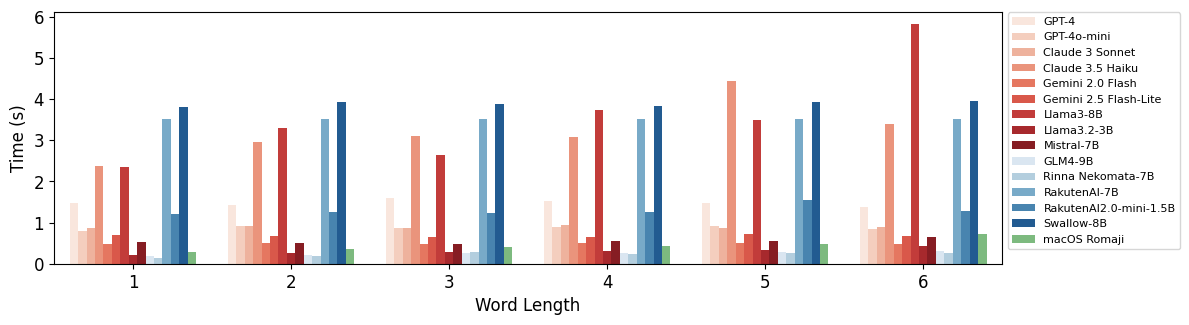

In [83]:
melted_df = pd.melt(data_melt.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')


# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length',fontsize=12)
plt.ylabel('Time (s)',fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_kanji_time_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



#### Hira

In [84]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [85]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna', 'swallow', 'sys_japanese','wana']

In [86]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()
columns

array([2, 5, 3, 4, 1, 6, 7, 8])

In [87]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
    for wl in columns:
        mask = (df['len'] == wl) & (df['AI_type'] == "hira")
        col_name = model + '_time'
        if col_name in df.columns:
            mean_val = df.loc[mask, col_name].mean()
            data.loc[model, wl] = mean_val


data

,2,5,3,4,1,6,7,8
claude3,0.925448,0.966797,0.795354,1.093473,NaN,0.816839,0.685972,NaN
llama32,0.211150,0.364149,0.270470,0.317592,NaN,0.428850,0.444983,NaN
gpt4o,0.795371,0.905386,0.935141,0.879260,NaN,0.798452,2.506641,NaN
rakuten,3.520555,3.515972,3.546496,3.519191,NaN,3.525679,3.508599,NaN
swallow,3.991936,3.967491,3.966871,3.973641,NaN,4.012583,3.980984,NaN
wana,0.000304,0.000340,0.000566,0.000409,NaN,0.001095,0.000342,NaN
gemini2,0.463070,0.526069,0.464176,0.489681,NaN,0.520051,0.511784,NaN
gpt35,0.718843,0.759931,0.743145,0.718591,NaN,0.798986,0.734919,NaN
gpt4,1.373685,1.465846,1.448219,1.461067,NaN,1.590442,1.369118,NaN
gemini,1.006982,1.402063,1.192741,1.233975,NaN,0.673770,0.740611,NaN


In [88]:
data_melt = data.drop(columns=[1,8])
melted_df = pd.melt(data_melt.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')
melted_df

,model,wl,time
0,GPT-4,2,1.373685
1,GPT-4o-mini,2,0.795371
2,Claude 3 Sonnet,2,0.925448
3,Claude 3.5 Haiku,2,2.423963
4,Gemini 2.0 Flash,2,0.463070
...,...,...,...
91,RakutenAI2.0-mini-1.5B,7,1.375546
92,Rinna Nekomata-7B,7,0.263038
93,Swallow-8B,7,3.980984
94,macOS Romaji,7,0.462126


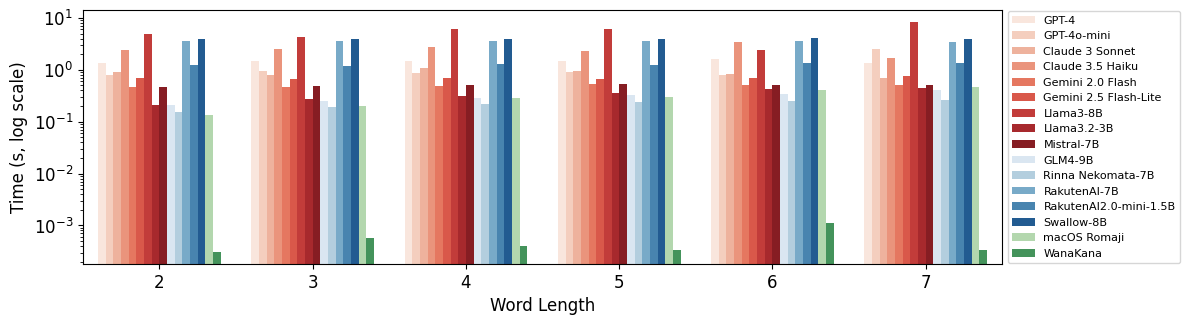

In [89]:
#melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku',  'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji', 'WanaKana']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length',fontsize=12)
plt.yscale('log')
plt.ylabel('Time (s, log scale)', fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_hira_time_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



#### Kata

In [90]:
df = load_results('Japanese Words_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

In [91]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35',  'gemini2','gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna','swallow', 'sys_japanese', 'wana']

In [92]:
# models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = df['len'].unique()
columns

array([2, 5, 3, 4, 1, 6, 7, 8])

In [93]:
for model in models:
  for wl in columns:
      if wl in [7, 8]:
          # 把7和8都视为同一个“7+”类别
          col_label = '7+'
          mask = (df['len'].isin([7, 8])) & (df['AI_type'] == 'kata')
      else:
          col_label = wl
          mask = (df['len'] == wl) & (df['AI_type'] == 'kata')

      col_name = model + '_time'
      if col_name in df.columns:
          mean_val = df.loc[mask, col_name].mean()
          data.loc[model, col_label] = mean_val

data

,2,5,3,4,1,6,7,8,7+
claude3,0.876470,0.701123,0.893587,0.856626,NaN,0.693606,0.685972,NaN,0.920477
llama32,0.225171,0.333779,0.242214,0.302382,NaN,0.405578,0.444983,NaN,0.444898
gpt4o,0.863673,0.790374,0.855994,0.836194,NaN,0.800197,2.506641,NaN,0.666539
rakuten,3.527442,3.563818,3.530211,3.529513,NaN,3.587939,3.508599,NaN,3.518228
swallow,3.667951,3.895825,3.826693,3.871963,NaN,3.694769,3.980984,NaN,3.949882
wana,0.000311,0.002647,0.000495,0.000491,NaN,0.000350,0.000342,NaN,0.002025
gemini2,0.484086,0.471488,0.466632,0.501095,NaN,0.478221,0.511784,NaN,0.486896
gpt35,0.690689,0.674080,0.733459,0.707544,NaN,0.666138,0.734919,NaN,0.669489
gpt4,1.397080,1.426083,1.354153,1.340378,NaN,1.411594,1.369118,NaN,1.414778
gemini,1.013512,0.872419,1.046003,1.213998,NaN,0.673001,0.740611,NaN,0.665281


In [94]:
data = data.drop(columns=[1,7,8])
desired_order = [2, 3, 4, 5, 6, '7+']
data_melt = data[desired_order]
melted_df = pd.melt(data_melt.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')
melted_df

,model,wl,time
0,GPT-4,2,1.397080
1,GPT-4o-mini,2,0.863673
2,Claude 3 Sonnet,2,0.876470
3,Claude 3.5 Haiku,2,3.228389
4,Gemini 2.0 Flash,2,0.484086
...,...,...,...
91,RakutenAI2.0-mini-1.5B,7+,1.428541
92,Rinna Nekomata-7B,7+,0.307966
93,Swallow-8B,7+,3.949882
94,macOS Romaji,7+,0.238191


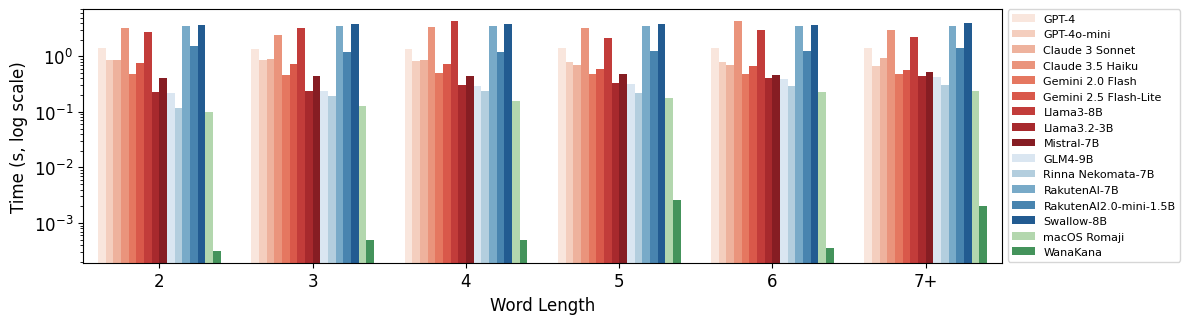

In [95]:
#melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji', 'WanaKana']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Word Length',fontsize=12)
plt.yscale('log')
plt.ylabel('Time (s, log scale)', fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jwg_kata_time_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



## Japanese Sentence Generation

In [14]:
df = load_results('Japanese Sentence_Generation')
models = extract_gen_models(df)
make_columns_numeric(df, models)

<Axes: xlabel='len', ylabel='Count'>

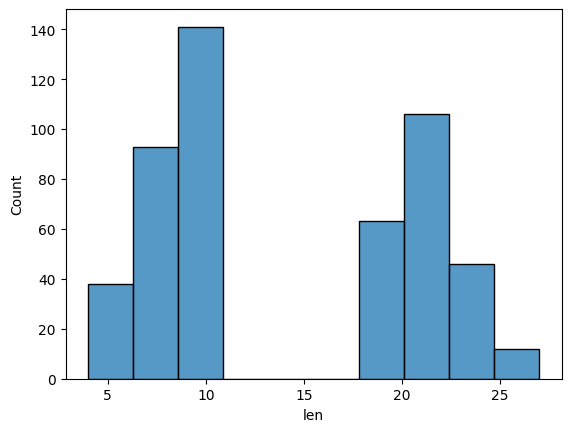

In [15]:
sns.histplot(df['len'])

In [16]:
# bucket of ranges
columns = ['<8', '8-16', '16-24', '24+']

df['len_bin'] = pd.cut(df['len'], bins=[0, 8, 16, 24, np.inf], labels=columns)


### Text Similarity Vs Sentence Length

In [17]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  for sl in columns:
    data.loc[model, sl] = df[df['len_bin'] == sl][model + '_simhash_textsim'].mean()

data

,<8,8-16,16-24,24+
mistral,0.641405,0.625023,0.633553,0.619577
gpt35,0.835933,0.820740,0.842577,0.825327
swallow,0.676528,0.695418,0.682486,0.678932
gemini25,0.846654,0.839059,0.774481,0.722286
claude3,0.849048,0.840928,0.811079,0.727227
llama3,0.693746,0.648548,0.644708,0.656303
sys_japanese,0.835146,0.799403,0.788899,0.720336
rakuten2,0.542226,0.517560,0.525287,0.511441
llama32,0.589000,0.591811,0.577220,0.588978
GLM4,0.602823,0.580501,0.583560,0.581081


In [18]:
models

['mistral',
 'gpt35',
 'swallow',
 'gemini25',
 'claude3',
 'llama3',
 'sys_japanese',
 'rakuten2',
 'llama32',
 'GLM4',
 'gemini',
 'gemini2',
 'gpt4o',
 'gpt4',
 'rakuten',
 'claude35',
 'rinna']

In [19]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2', 'rinna', 'swallow','sys_japanese']

In [20]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')
melted_df

,model,wl,textsim
0,GPT-4,<8,0.905082
1,GPT-4o-mini,<8,0.870284
2,Claude 3 Sonnet,<8,0.849048
3,Claude 3.5 Haiku,<8,0.762483
4,Gemini 2.0 Flash,<8,0.906381
5,Gemini 2.5 Flash-Lite,<8,0.846654
6,Llama3-8B,<8,0.693746
7,Llama3.2-3B,<8,0.589000
8,Mistral-7B,<8,0.641405
9,GLM4-9B,<8,0.602823


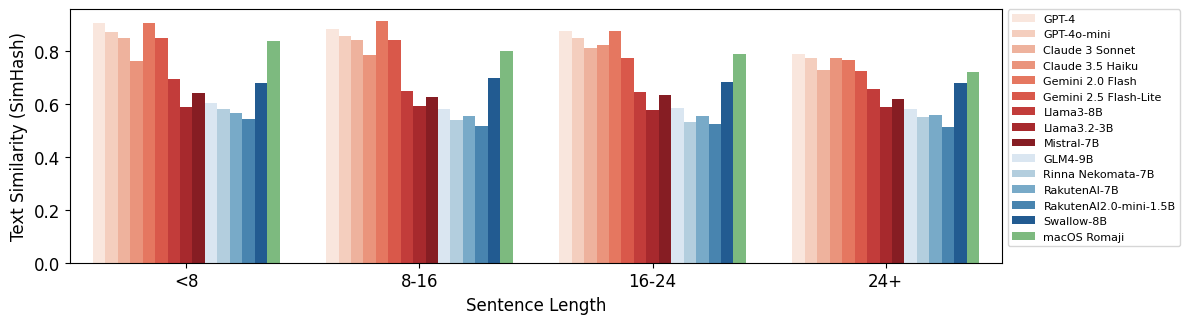

In [21]:
#melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Sentence Length',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jsg_textsim_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



### Time Vs Sentence Length

In [22]:
models

['mistral',
 'gpt35',
 'swallow',
 'gemini25',
 'claude3',
 'llama3',
 'sys_japanese',
 'rakuten2',
 'llama32',
 'GLM4',
 'gemini',
 'gemini2',
 'gpt4o',
 'gpt4',
 'rakuten',
 'claude35',
 'rinna']

In [23]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  for sl in columns:
    # 1. Extract the subset of data
        subset = df.loc[df['len_bin'] == sl, model + '_time']

        # 2. Replace empty strings '' with NaN (if the column is not already numeric)
        subset = subset.replace('', np.nan)

        # 3. Convert to numeric type (any values that cannot be converted will become NaN)
        subset = pd.to_numeric(subset, errors='coerce')

        # 4. Calculate the mean; mean() will automatically skip NaN values
        data.loc[model, sl] = subset.mean()

data

,<8,8-16,16-24,24+
mistral,0.598282,0.667821,0.936895,1.054609
gpt35,0.893799,0.967216,1.186480,1.304156
swallow,10.108712,10.110835,10.115872,10.108924
gemini25,0.672835,0.696993,0.696342,0.680172
claude3,1.328298,1.412287,1.931802,1.958676
llama3,4.212623,4.409934,4.816209,5.068538
sys_japanese,0.113887,0.216934,1.419656,1.575364
rakuten2,1.471416,1.632700,2.320733,2.296645
llama32,0.453317,0.553075,0.913521,1.096516
GLM4,1.664912,1.793526,2.317118,2.312318


In [24]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2','gemini25',
                'llama3', 'llama32', 'mistral', 'GLM4', 'rakuten', 'rakuten2','swallow', 'rinna', 'sys_japanese']

In [25]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

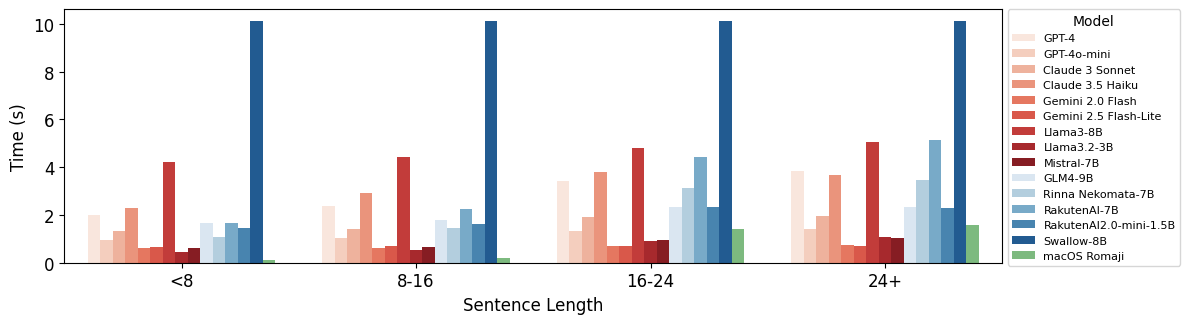

In [26]:
melted_df = pd.melt(data.reindex(models_order).rename(index=MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o-mini', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B', 'Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Traditional IMEs': ['macOS Romaji']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    'Traditional IMEs': sns.color_palette('Greens', n_colors=len(model_categories['Traditional IMEs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Traditional IMEs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Sentence Length',fontsize=12)
plt.ylabel('Time (s)',fontsize=12)
# plt.title('Chinese Sentence Generation: Text Similarity vs Sentence Length by Model Category')
plt.legend(title='Model', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jsg_time_wl.pdf', format='pdf', bbox_inches='tight')
plt.show()



## Chinese Error Correction

In [ ]:
df = load_results('Chinese Error Correction')
models = extract_err_models(df) # Use error correction extraction

# Make Columns Numeric
for model in models:
  df[model + '_incorrectstrings_simhash_textsim'] = pd.to_numeric(df[model + '_incorrectstrings_simhash_textsim'], errors='coerce')
  df[model + '_incorrectstrings_time'] = pd.to_numeric(df[model + '_incorrectstrings_time'], errors='coerce')

  if model == 'pycorrector':
    continue

  df[model + '_pinyin_simhash_textsim'] = pd.to_numeric(df[model + '_pinyin_simhash_textsim'], errors='coerce')
  df[model + '_pinyin_time'] = pd.to_numeric(df[model + '_pinyin_time'], errors='coerce')

In [ ]:
models

['pycorrector',
 'mistral',
 'llama3',
 'gpt4',
 'claude3',
 'baichuan2',
 'gemini25',
 'gpt4o',
 'qwen2',
 'GLM4',
 'gemini2',
 'claude35',
 'llama32']

In [ ]:
models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns_index = pd.MultiIndex.from_tuples([('textsim', 'valid'), ('textsim', 'invalid'), ('time', 'valid'), ('time', 'invalid')])

In [ ]:
mean_df = pd.DataFrame(index=models_index, columns=columns_index, dtype='float64')

valid_df = df[df['pseudo_type'] == 'valid']
invalid_df = df[df['pseudo_type'] == 'invalid']

for model in models:
  if model == 'pycorrector':
    mean_df.drop(index=(get_model_type(model), model), inplace=True)
    continue

  mean_df.loc[(get_model_type(model), model), ('textsim', 'valid'),] = valid_df[model + '_pinyin_simhash_textsim'].mean()
  mean_df.loc[(get_model_type(model), model), ('textsim', 'invalid'),] = invalid_df[model + '_pinyin_simhash_textsim'].mean()
  mean_df.loc[(get_model_type(model), model), ('time', 'valid')] = valid_df[model + '_pinyin_time'].mean()
  mean_df.loc[(get_model_type(model), model), ('time', 'invalid')] = invalid_df[model + '_pinyin_time'].mean()

In [ ]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2']
mean_df.droplevel(0, axis=0).reindex(models_order).rename(MODELS_METADATA['Name'].to_dict())

textsim                time          
                          valid   invalid     valid   invalid
GPT-4                  0.719608  0.731252  5.747289  5.013921
GPT-4o-mini            0.754258  0.736791  2.637292  2.316440
Claude 3 Sonnet        0.660569  0.652341  2.949365  3.001667
Claude 3.5 Haiku       0.674424  0.657498  7.559695  7.619488
Gemini 2.0 Flash       0.784285  0.805815  1.144401  1.081932
Gemini 2.5 Flash-Lite  0.661506  0.650737  0.628406  0.619409
Llama3-8B              0.557762  0.557128  2.179124  2.298702
Llama3.2-3B            0.527973  0.525063  1.063703  1.031511
Mistral-7B             0.540965  0.539335  3.178654  3.236423
GLM4-9B                0.570493  0.563512  1.442356  1.696253
Baichuan2-7B           0.532755  0.526710  1.986287  1.709568
Qwen2-7B               0.556664  0.554559  2.541025  2.661191

### Pinyin: Textsim vs Noise

In [ ]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35','gemini2','gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2']
columns = sorted(df['noise_num'].unique())

In [ ]:
df['noise_num'].unique()

array([1, 2, 0, 3, 4, 5])

In [ ]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  if model == 'pycorrector':
    data.drop(index=model, inplace=True)
    continue

  for num in columns:
    data.loc[model, num] = df[df['noise_num'] == num][model + '_pinyin_simhash_textsim'].mean()

data

,0,1,2,3,4,5
gpt4,0.762072,0.762164,0.732845,0.704162,0.658728,0.629009
gpt4o,0.804771,0.789934,0.763093,0.732638,0.670715,0.655341
claude3,0.688260,0.681964,0.667152,0.639973,0.617970,0.606321
claude35,0.711480,0.696895,0.677423,0.646430,0.624055,0.613429
gemini2,0.831394,0.840326,0.802347,0.762847,0.698823,0.692480
gemini25,0.690612,0.692737,0.663451,0.640674,0.614070,0.587374
llama3,0.557194,0.563906,0.564974,0.560716,0.536007,0.543474
llama32,0.515402,0.530306,0.525135,0.525190,0.534890,0.530161
mistral,0.541796,0.538707,0.543434,0.544930,0.539443,0.535175
GLM4,0.595205,0.579258,0.563510,0.568432,0.547217,0.546863


In [ ]:
melted_df = pd.melt(data.rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

melted_df

,model,wl,textsim
0,GPT-4,0,0.762072
1,GPT-4o,0,0.804771
2,Claude 3 Sonnet,0,0.688260
3,Claude 3.5 Haiku,0,0.711480
4,Gemini 2.0 Flash,0,0.831394
...,...,...,...
67,Llama3.2-3B,5,0.530161
68,Mistral-7B,5,0.535175
69,GLM4-9B,5,0.546863
70,Baichuan2-7B,5,0.528358


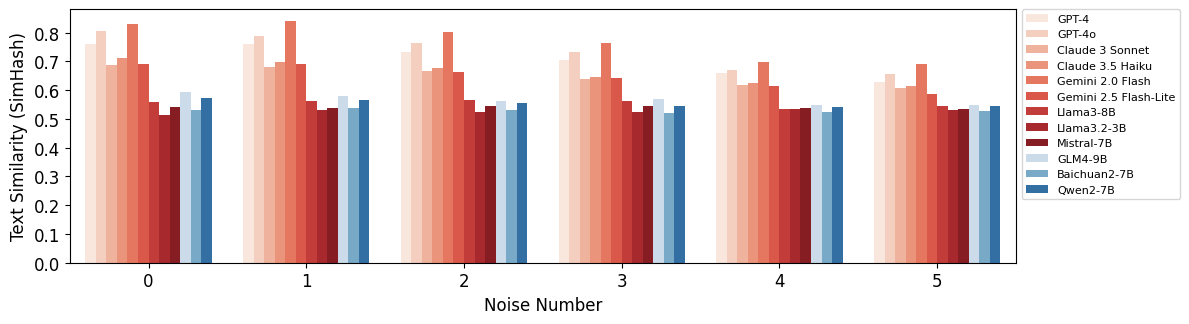

In [ ]:

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Baichuan2-7B', 'Qwen2-7B'],
    #'Chinese LLMs': []
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    #'Chinese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Chinese LLMs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/cec_pinyin_textsim_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Pinyin: Time vs Noise

In [ ]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2', 'gemini25', 'llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2']
columns = sorted(df['noise_num'].unique())

In [ ]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  if model == 'pycorrector':
    data.drop(index=model, inplace=True)
    continue

  for num in columns:
    data.loc[model, num] = df[df['noise_num'] == num][model + '_pinyin_time'].mean()

data

,0,1,2,3,4,5
gpt4,5.790984,5.441770,5.752264,6.010199,5.454220,5.079474
gpt4o,2.537028,2.538193,2.719004,2.554536,2.537666,2.386129
claude3,2.728130,2.816781,2.772036,3.432519,3.409344,3.033512
claude35,7.056798,7.288938,7.753112,8.001980,7.912699,7.712806
gemini2,0.937131,1.450394,1.004597,1.080710,0.819774,1.060361
gemini25,0.632311,0.599410,0.682421,0.615936,0.615100,0.601154
llama3,2.103868,2.123828,2.395858,2.246522,2.209659,2.090864
llama32,1.051567,1.051256,1.065684,1.065828,1.072133,1.030261
mistral,2.860377,3.317886,3.456503,3.122445,2.959677,2.924974
GLM4,1.268254,1.719817,1.569995,1.319213,1.313093,1.342435


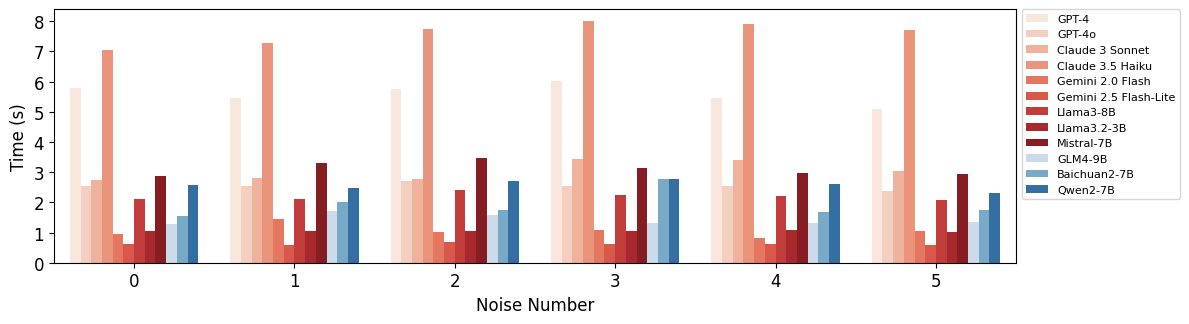

In [ ]:
melted_df = pd.melt(data.reindex(models_order).rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Baichuan2-7B', 'Qwen2-7B'],
    #'Chinese LLMs': []
}


# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    #'Chinese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Chinese LLMs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Time (s)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/cec_pinyin_time_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Chinese Characters: Textsim vs Noise

In [ ]:
df = load_results('Chinese Error Correction')
models = extract_err_models(df) # Use error correction extraction

# Make Columns Numeric
for model in models:
  df[model + '_incorrectstrings_simhash_textsim'] = pd.to_numeric(df[model + '_incorrectstrings_simhash_textsim'], errors='coerce')
  df[model + '_incorrectstrings_time'] = pd.to_numeric(df[model + '_incorrectstrings_time'], errors='coerce')

  if model == 'pycorrector':
    continue

  df[model + '_pinyin_simhash_textsim'] = pd.to_numeric(df[model + '_pinyin_simhash_textsim'], errors='coerce')
  df[model + '_pinyin_time'] = pd.to_numeric(df[model + '_pinyin_time'], errors='coerce')

In [ ]:
mean_df = pd.DataFrame(index=models_index, columns=['textsim', 'time'], dtype='float64')

for model in models:
  mean_df.loc[(get_model_type(model), model), 'textsim',] = valid_df[model + '_incorrectstrings_simhash_textsim'].mean()
  mean_df.loc[(get_model_type(model), model), 'time',] = invalid_df[model + '_incorrectstrings_time'].mean()

In [ ]:
models_order = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2', 'pycorrector']
mean_df.droplevel(0, axis=0).reindex(models_order).rename(MODELS_METADATA['Name'].to_dict())

,textsim,time
GPT-4,0.819060,4.781005
GPT-4o-mini,0.861047,1.645145
Claude 3 Sonnet,0.783660,2.987533
Claude 3.5 Haiku,0.794213,6.783265
Gemini 2.0 Flash,0.802623,0.874799
Gemini 2.5 Flash-Lite,0.753655,0.612107
Llama3-8B,0.719284,2.396866
Llama3.2-3B,0.675337,1.101990
Mistral-7B,0.700873,2.277959
GLM4-9B,0.727086,1.546603


In [ ]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2', 'pycorrector']
columns = sorted(df['noise_num'].unique())

In [ ]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  for num in columns:
    data.loc[model, num] = df[df['noise_num'] == num][model + '_incorrectstrings_simhash_textsim'].mean()

data

,0,1,2,3,4,5
gpt4,0.892677,0.812932,0.765604,0.697383,0.666238,0.653898
gpt4o,0.913133,0.846963,0.803789,0.744429,0.705167,0.697820
claude3,0.837880,0.773611,0.738697,0.690063,0.648478,0.635173
claude35,0.867006,0.793300,0.747796,0.684857,0.646379,0.630325
gemini2,0.854452,0.797341,0.745655,0.709097,0.659835,0.649014
gemini25,0.820385,0.756608,0.699510,0.660250,0.627152,0.615149
llama3,0.764128,0.717095,0.678852,0.642429,0.620774,0.607835
llama32,0.740295,0.676122,0.642873,0.608877,0.587300,0.582306
mistral,0.739562,0.698401,0.663015,0.627464,0.607931,0.601301
GLM4,0.795238,0.730352,0.680608,0.638257,0.615063,0.595770


In [ ]:
melted_df = pd.melt(data.rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

melted_df

,model,wl,textsim
0,GPT-4,0,0.892677
1,GPT-4o,0,0.913133
2,Claude 3 Sonnet,0,0.837880
3,Claude 3.5 Haiku,0,0.867006
4,Gemini 2.0 Flash,0,0.854452
...,...,...,...
73,Mistral-7B,5,0.601301
74,GLM4-9B,5,0.595770
75,Baichuan2-7B,5,0.572246
76,Qwen2-7B,5,0.607160


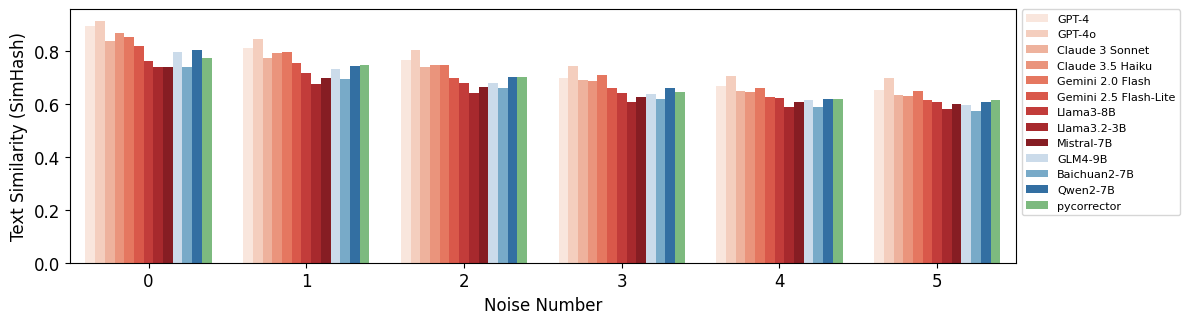

In [ ]:
# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Baichuan2-7B', 'Qwen2-7B'],
    #'Chinese LLMs': [],
    'Baselines': ['pycorrector']
}


# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    #'Chinese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Chinese LLMs'])),
    'Baselines': sns.color_palette('Greens', n_colors=len(model_categories['Baselines']))
}#no greys

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs','Baselines']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/cec_char_textsim_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Chinese Characters: Time vs Noise

In [ ]:
df = load_results('Chinese Error Correction')
models = extract_err_models(df) # Use error correction extraction

# Make Columns Numeric
for model in models:
  df[model + '_incorrectstrings_simhash_textsim'] = pd.to_numeric(df[model + '_incorrectstrings_simhash_textsim'], errors='coerce')
  df[model + '_incorrectstrings_time'] = pd.to_numeric(df[model + '_incorrectstrings_time'], errors='coerce')

  if model == 'pycorrector':
    continue

  df[model + '_pinyin_simhash_textsim'] = pd.to_numeric(df[model + '_pinyin_simhash_textsim'], errors='coerce')
  df[model + '_pinyin_time'] = pd.to_numeric(df[model + '_pinyin_time'], errors='coerce')

In [ ]:
mean_df = pd.DataFrame(index=models_index, columns=['textsim', 'time'], dtype='float64')

for model in models:
  mean_df.loc[(get_model_type(model), model), 'textsim',] = valid_df[model + '_incorrectstrings_simhash_textsim'].mean()
  mean_df.loc[(get_model_type(model), model), 'time',] = invalid_df[model + '_incorrectstrings_time'].mean()

In [ ]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35',  'gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4', 'baichuan2', 'qwen2', 'pycorrector']
columns = sorted(df['noise_num'].unique())

In [ ]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  for num in columns:
    data.loc[model, num] = df[df['noise_num'] == num][model + '_incorrectstrings_time'].mean()

data

,0,1,2,3,4,5
gpt4,4.117095,4.708916,4.491046,4.447469,4.192121,4.507755
gpt4o,1.457312,1.457629,1.522656,1.527574,1.562446,1.551949
claude3,2.162300,2.230247,2.352222,2.539257,2.456310,2.559798
claude35,4.832253,5.636647,5.597691,5.772633,5.957222,5.582125
gemini2,0.725497,1.238491,0.853916,0.996638,0.686406,0.805299
gemini25,0.500052,0.551500,0.544339,0.522494,0.531133,0.535334
llama3,1.969811,1.922528,2.124040,2.065022,2.131532,2.033992
llama32,1.066848,1.061737,1.097959,1.092125,1.078080,1.074412
mistral,2.176832,2.172674,2.263685,2.226630,2.182767,2.178702
GLM4,1.088296,1.119781,1.238588,1.232654,1.228405,1.212022


In [ ]:
melted_df = pd.melt(data.reindex(models).rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

melted_df

,model,wl,time
0,GPT-4,0,4.117095
1,GPT-4o,0,1.457312
2,Claude 3 Sonnet,0,2.162300
3,Claude 3.5 Haiku,0,4.832253
4,Gemini 2.0 Flash,0,0.725497
...,...,...,...
73,Mistral-7B,5,2.178702
74,GLM4-9B,5,1.212022
75,Baichuan2-7B,5,1.562187
76,Qwen2-7B,5,1.973321


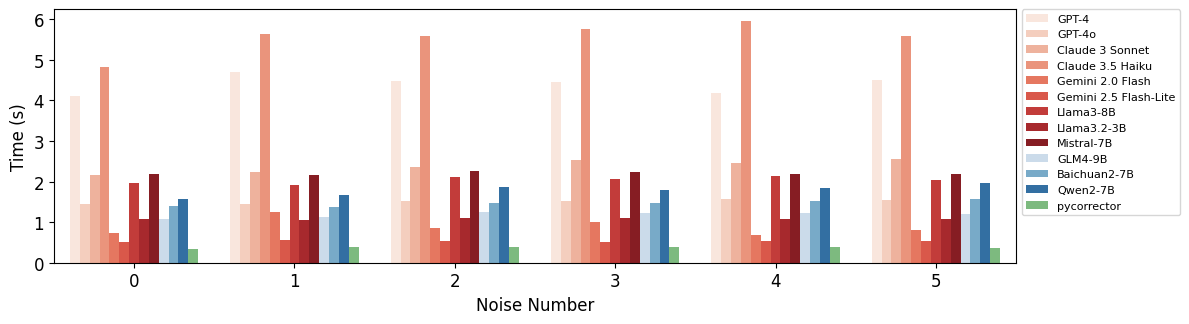

In [ ]:
# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku','Gemini 2.0 Flash', 'Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Baichuan2-7B', 'Qwen2-7B'],
    #'Chinese LLMs': [],
    'Baselines': ['pycorrector']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    #'Chinese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Chinese LLMs'])),
    'Baselines': sns.color_palette('Greens', n_colors=len(model_categories['Baselines']))
}#no greys

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs','Baselines']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Time (s)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/cec_char_time_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Japanese Error Correction

In [34]:
df = load_results('Japanese Error Correction')
models = extract_err_models(df) # Use error correction extraction


In [ ]:

# Make Columns Numeric
for model in models:
  df[model + '_incorrectstrings_simhash_textsim'] = pd.to_numeric(df[model + '_incorrectstrings_simhash_textsim'], errors='coerce')
  df[model + '_incorrectstrings_time'] = pd.to_numeric(df[model + '_incorrectstrings_time'], errors='coerce')


  df[model + '_romanji_simhash_textsim'] = pd.to_numeric(df[model + '_romanji_simhash_textsim'], errors='coerce')
  df[model + '_romanji_time'] = pd.to_numeric(df[model + '_romanji_time'], errors='coerce')

In [35]:
models

['mistral',
 'gpt35',
 'swallow',
 'gemini25',
 'claude3',
 'llama3',
 'rakuten2',
 'llama32',
 'GLM4',
 'gemini',
 'gemini2',
 'gpt4o',
 'gpt4',
 'rakuten',
 'claude35',
 'opennmt',
 'rinna']

In [ ]:
"""
models_index = pd.MultiIndex.from_tuples([(get_model_type(x), x) for x in models]).sort_values()
columns = ['textsim', 'time']

Create and populate the DataFrame.

### Romanji: Romanji vs Noise

In [36]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4','rinna', 'rakuten','swallow', 'rakuten2']
columns = sorted(df['noise_num'].unique())

In [37]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  if model == 'opennmt':
    data.drop(index=model, inplace=True)
    continue

  for num in columns:
    data.loc[model, num] = df[df['noise_num'] == num][model + '_romanji_simhash_textsim'].mean()

data

,0,1,2
gpt4,0.818681,0.812697,0.824690
gpt4o,0.871426,0.852585,0.858725
claude3,0.763524,0.735036,0.730840
claude35,0.789198,0.789179,0.779024
gemini2,0.858459,0.839631,0.861460
gemini25,0.748958,0.761528,0.736257
llama3,0.588207,0.594517,0.599776
llama32,0.536570,0.540705,0.532243
mistral,0.576515,0.579954,0.579371
GLM4,0.554261,0.561795,0.553307


In [38]:
melted_df = pd.melt(data.rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

melted_df

,model,wl,textsim
0,GPT-4,0,0.818681
1,GPT-4o,0,0.871426
2,Claude 3 Sonnet,0,0.763524
3,Claude 3.5 Haiku,0,0.789198
4,Gemini 2.0 Flash,0,0.858459
5,Gemini 2.5 Flash-Lite,0,0.748958
6,Llama3-8B,0,0.588207
7,Llama3.2-3B,0,0.536570
8,Mistral-7B,0,0.576515
9,GLM4-9B,0,0.554261


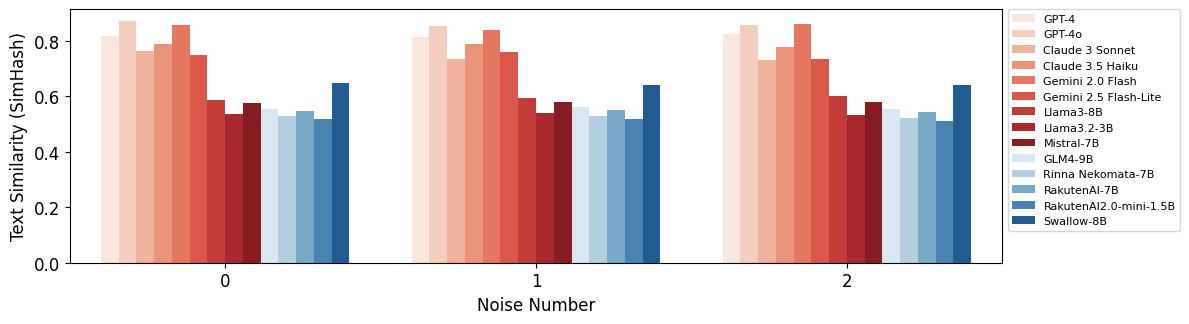

In [39]:

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash', 'Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Rinna Nekomata-7B', 'RakutenAI-7B', 'RakutenAI2.0-mini-1.5B','Swallow-8B']
    #'Japanese LLMs': []
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs']))
    #'Japanese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Japanese LLMs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jec_romanji_textsim_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Romanji: Time vs Noise

In [40]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4','rinna', 'rakuten', 'rakuten2','swallow']
columns = sorted(df['noise_num'].unique())

In [41]:
# 将所有 *_romanji_time 列转换为 float，非数值会自动变成 NaN
for col in df.columns:
    if col.endswith("_romanji_time"):
        df[col] = pd.to_numeric(df[col], errors="coerce")



In [42]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  if model == 'opennmt':
    data.drop(index=model, inplace=True)
    continue

  for num in columns:
    data.loc[model, num] = df[df['noise_num'] == num][model + '_romanji_time'].mean()

data

,0,1,2
gpt4,4.269180,5.187075,4.216916
gpt4o,1.855902,1.899087,1.933879
claude3,2.721350,2.941623,2.769064
claude35,6.464657,6.582800,6.418501
gemini2,0.684160,0.748128,0.738275
gemini25,0.768523,0.795124,0.754069
llama3,3.352618,3.573543,3.269392
llama32,1.170240,1.178681,1.171615
mistral,2.655636,2.859298,2.710118
GLM4,10.134959,6.244035,6.045826


In [43]:
melted_df = pd.melt(data.rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

melted_df

,model,wl,time
0,GPT-4,0,4.269180
1,GPT-4o,0,1.855902
2,Claude 3 Sonnet,0,2.721350
3,Claude 3.5 Haiku,0,6.464657
4,Gemini 2.0 Flash,0,0.684160
5,Gemini 2.5 Flash-Lite,0,0.768523
6,Llama3-8B,0,3.352618
7,Llama3.2-3B,0,1.170240
8,Mistral-7B,0,2.655636
9,GLM4-9B,0,10.134959


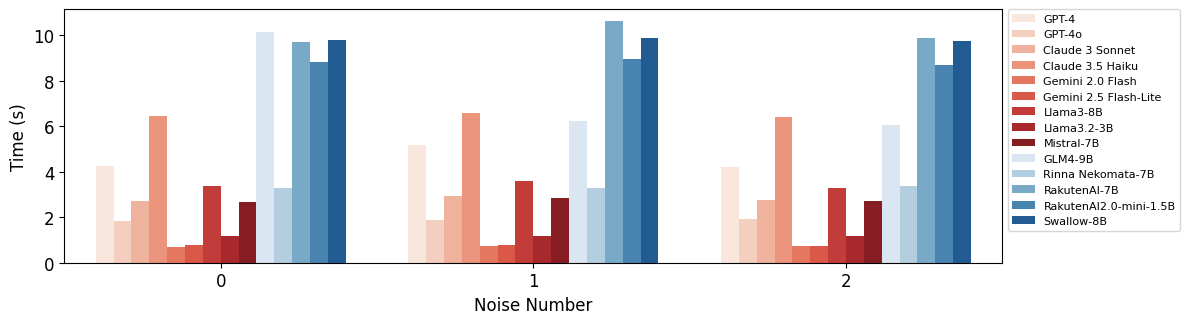

In [44]:

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash', 'Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Rinna Nekomata-7B', 'RakutenAI-7B', 'RakutenAI2.0-mini-1.5B','Swallow-8B']
    #'Japanese LLMs': []
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    #'Japanese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Japanese LLMs']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Time (s)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jec_romanji_time_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Japanese Characters: Textsim vs Noise

In [45]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35', 'gemini2', 'gemini25','llama3', 'llama32', 'mistral','GLM4', 'rinna', 'rakuten', 'rakuten2','swallow','opennmt']
columns = sorted(df['noise_num'].unique())

In [46]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:

  for num in columns:
    data.loc[model, num] = df[df['noise_num'] == num][model + '_incorrectstrings_simhash_textsim'].mean()

data

,0,1,2
gpt4,0.906743,0.927268,0.908027
gpt4o,0.957896,0.954471,0.961239
claude3,0.866853,0.875458,0.848061
claude35,0.879156,0.917103,0.887761
gemini2,0.870698,0.873835,0.871365
gemini25,0.867730,0.933853,0.868371
llama3,0.820499,0.845560,0.836860
llama32,0.716504,0.711575,0.718139
mistral,0.790547,0.803224,0.790315
GLM4,0.823937,0.850206,0.835720


In [47]:
melted_df = pd.melt(data.rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='textsim')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

melted_df

,model,wl,textsim
0,GPT-4,0,0.906743
1,GPT-4o,0,0.957896
2,Claude 3 Sonnet,0,0.866853
3,Claude 3.5 Haiku,0,0.879156
4,Gemini 2.0 Flash,0,0.870698
5,Gemini 2.5 Flash-Lite,0,0.867730
6,Llama3-8B,0,0.820499
7,Llama3.2-3B,0,0.716504
8,Mistral-7B,0,0.790547
9,GLM4-9B,0,0.823937


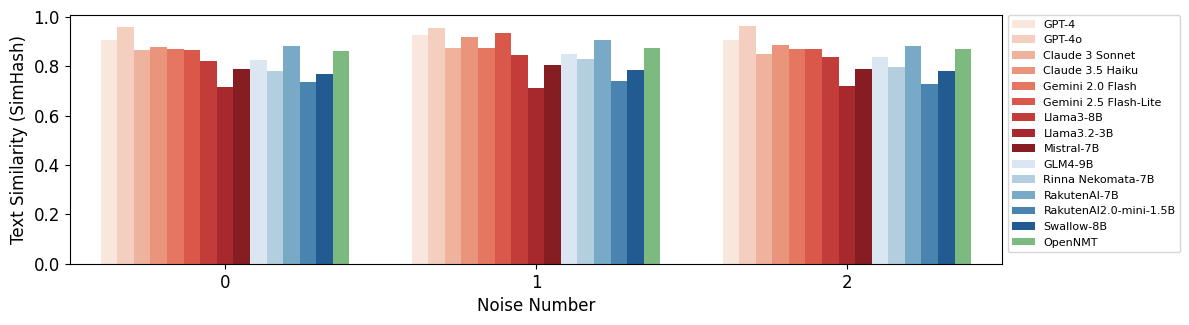

In [48]:
# Define model categories
'''
model_categories = {
    'Closed-Source LLMs': ['GPT3.5', 'GPT4', 'GPT4o', 'Claude3 Sonnet', 'Claude3.5 Haiku', 'Gemini1.5 Flash', 'Gemini2.0 Flash'],
    'Open-Source LLMs': ['Llama3-8B', 'Llama3.2-3B', 'Mistral-7B', 'GLM4-9B'],
    'Japanese LLMs': ['Rinna Nekomata-7B', 'RakutenAI-7B','RakutenAI2.0-mini','Swallow-8B'],
    'Baselines': ['OpenNMT']
}
'''

model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash', 'Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Rinna Nekomata-7B', 'RakutenAI-7B', 'RakutenAI2.0-mini-1.5B','Swallow-8B'],
    'Baselines': ['OpenNMT']
}


# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    #'Japanese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Japanese LLMs'])),
    'Baselines': sns.color_palette('Greens', n_colors=len(model_categories['Baselines']))
}
# no Greys

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs', 'Baselines']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='textsim', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Text Similarity (SimHash)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()

plt.savefig(f'{FIGURES_FOLDER}/jec_char_textsim_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Japanese Characters: Time vs Noise

In [49]:
df = load_results('Japanese Error Correction')
models = extract_err_models(df) # Use error correction extraction

In [50]:
models = ['gpt4', 'gpt4o', 'claude3', 'claude35','gemini2', 'gemini25','llama3', 'llama32', 'mistral', 'GLM4','rinna', 'rakuten', 'rakuten2','swallow','opennmt']
columns = sorted(df['noise_num'].unique())

In [51]:
df['noise_num'].unique()

array([1, 2, 0])

In [52]:
data = pd.DataFrame(index=models, columns=columns, dtype='float64')

for model in models:
  for num in columns:
    data.loc[model, num] = pd.to_numeric(
    df[df['noise_num'] == num][model + "_incorrectstrings_time"],
    errors='coerce').mean()
    #data.loc[model, num] = df[df['noise_num'] == num][model + "_incorrectstrings_time"].mean()

data

,0,1,2
gpt4,5.181492,5.731329,5.198167
gpt4o,1.600764,1.700403,1.608706
claude3,2.055810,2.227336,2.058547
claude35,4.594626,4.688148,4.595862
gemini2,0.946324,1.100044,1.036659
gemini25,0.559880,0.584564,0.571139
llama3,2.952271,3.247559,3.004440
llama32,1.151569,1.162613,1.152596
mistral,2.449726,2.578685,2.435047
GLM4,2.284080,2.557939,3.192033


In [53]:
melted_df = pd.melt(data.rename(MODELS_METADATA['Name'].to_dict()).
                    reset_index(names=['model']), id_vars='model', var_name='wl', value_name='time')

#rename GPT4o Mini to GPT4o
melted_df['model'] = melted_df['model'].replace('GPT-4o-mini', 'GPT-4o')

melted_df

,model,wl,time
0,GPT-4,0,5.181492
1,GPT-4o,0,1.600764
2,Claude 3 Sonnet,0,2.055810
3,Claude 3.5 Haiku,0,4.594626
4,Gemini 2.0 Flash,0,0.946324
5,Gemini 2.5 Flash-Lite,0,0.559880
6,Llama3-8B,0,2.952271
7,Llama3.2-3B,0,1.151569
8,Mistral-7B,0,2.449726
9,GLM4-9B,0,2.284080


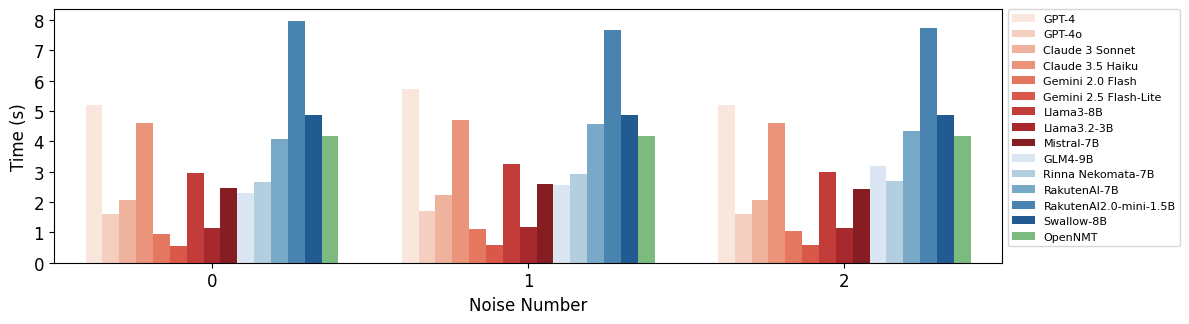

In [54]:

# Define model categories
model_categories = {
    'Closed-Source LLMs': ['GPT-4', 'GPT-4o', 'Claude 3 Sonnet', 'Claude 3.5 Haiku', 'Gemini 2.0 Flash','Gemini 2.5 Flash-Lite','Llama3-8B', 'Llama3.2-3B', 'Mistral-7B'],
    'Open-Source LLMs': ['GLM4-9B','Rinna Nekomata-7B', 'RakutenAI-7B', 'RakutenAI2.0-mini-1.5B','Swallow-8B'],
    #'Japanese LLMs': [],
    'Baselines': ['OpenNMT']
}

# Assign a category to each model
category_map = {model: cat for cat, models in model_categories.items() for model in models}
melted_df['category'] = melted_df['model'].map(category_map)

# Create a color palette grouped by categories
palette = {
    'Closed-Source LLMs': sns.color_palette('Reds', n_colors=len(model_categories['Closed-Source LLMs'])),
    'Open-Source LLMs': sns.color_palette('Blues', n_colors=len(model_categories['Open-Source LLMs'])),
    #'Japanese LLMs': sns.color_palette('Greens', n_colors=len(model_categories['Japanese LLMs'])),
    'Baselines': sns.color_palette('Greens', n_colors=len(model_categories['Baselines']))
}

# Flatten the palette colors to match the model order in the dataframe
flat_palette = []
for cat in ['Closed-Source LLMs', 'Open-Source LLMs','Baselines']:
    flat_palette.extend(palette[cat])

# Order the models according to categories for consistent plotting
ordered_models = sum(model_categories.values(), [])

plt.figure(figsize=(12, 3.35))
sns.barplot(x='wl', y='time', hue='model', data=melted_df, hue_order=ordered_models, palette=flat_palette)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Noise Number',fontsize=12)
plt.ylabel('Time (s)',fontsize=12)
# plt.title('Chinese Word Generation: Text Similarity vs Word Length by Model Category')
plt.legend(title='', bbox_to_anchor=(1.0, 1.02), loc='upper left', fontsize=8)
plt.tight_layout()


plt.savefig(f'{FIGURES_FOLDER}/jec_char_time_noise.pdf', format='pdf', bbox_inches='tight')
plt.show()